
# Stochastic Gradient Descent (SGD) Regressor From Scratch

## Multiple Linear Regression using SGD

This notebook demonstrates how to build a **Stochastic Gradient Descent Regressor** completely from scratch using only NumPy.

### What this project covers
- Multiple Linear Regression
- Gradient Descent Optimization
- Stochastic Gradient Descent (SGD)
- Manual parameter updates
- Model training & prediction
- R² score evaluation
- Comparison with Scikit-learn

---

## Why SGD?

Instead of computing gradients on the entire dataset at once, **SGD updates weights using one random training sample at a time**.

### Advantages
- Faster on large datasets
- Uses less memory
- Can escape shallow local minima
- Commonly used in real-world ML systems

---

## Mathematical Intuition

For Multiple Linear Regression:




The prediction equation is:

$$
\hat{y} = w_1x_1 + w_2x_2 + \dots + w_nx_n + b
$$

The SGD update rule:

$$
w := w - \eta \frac{\partial L}{\partial w}
$$

$$
b := b - \eta \frac{\partial L}{\partial b}
$$

Where:

- $ \eta $ = learning rate
- $ L $ = loss function
- $ w $ = weights
- $ b $ = bias/intercept

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import SGDRegressor

plt.rcParams["figure.figsize"] = (8,5)



# Step 1 — Load Dataset

We will use the famous **Diabetes Dataset** from Scikit-learn.

### Dataset Information
- 10 input features
- Continuous target variable
- Regression problem


In [2]:
X, y = load_diabetes(return_X_y=True)

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)


Feature Shape: (442, 10)
Target Shape : (442,)



# Step 2 — Train Test Split

We split the data into:
- 80% training data
- 20% testing data


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape: (353, 10)
Testing Shape : (89, 10)



# Step 3 — Implement SGD Regressor From Scratch

Below is the complete implementation of our custom SGD Regressor.

### Key Components
- Random sample selection
- Weight updates
- Bias updates
- Prediction function


In [8]:

class StochasticGradientDescent:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.initial_lr = learning_rate
        self.epochs = epochs
        self.intercept_ = None
        self.coef_ = None
        self.loss_history = []
        self.lr_history = []

    # Learning Rate Schedule
    def learning_schedule(self, epoch):
        return self.initial_lr / (1 + 0.01 * epoch)

    def fit(self, X_train, y_train):

        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for epoch in range(self.epochs):

            current_lr = self.learning_schedule(epoch)
            self.lr_history.append(current_lr)

            for i in range(X_train.shape[0]):

                idx = np.random.randint(0, X_train.shape[0])

                y_hat = np.dot(X_train[idx], self.coef_) + self.intercept_

                intercept_derivative = -2 * (y_train[idx] - y_hat)

                self.intercept_ = self.intercept_ - (current_lr * intercept_derivative)

                coef_derivative = -2 * np.dot((y_train[idx] - y_hat), X_train[idx])

                self.coef_ = self.coef_ - (current_lr * coef_derivative)

            # Calculate loss after each epoch
            y_pred = np.dot(X_train, self.coef_) + self.intercept_
            loss = np.mean((y_train - y_pred) ** 2)

            self.loss_history.append(loss)

        return self

    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_



# Step 4 — Train the Model

Now we initialize and train our custom model.


In [9]:
sgd = StochasticGradientDescent(
    learning_rate=0.01,
    epochs=100
)

sgd.fit(X_train, y_train)

print("Training Completed!")


Training Completed!



# Step 5 — Predictions

Use the trained model to predict values on unseen test data.


In [10]:
y_pred = sgd.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])


First 10 Predictions:
[153.34232156 193.85043713 136.75415539 106.82372831 252.55386513
 243.46353651 108.05420387 114.62695415  92.65405592 186.83214917]



# Step 6 — Evaluate Model Performance

We evaluate using **R² Score**.

### R² Interpretation
- 1.0 → Perfect prediction
- 0.0 → Model predicts mean only
- Negative → Very poor model


In [11]:
score = r2_score(y_test, y_pred)

print("Custom SGD R² Score:", round(score, 4))


Custom SGD R² Score: 0.4452



# Learning Rate Scheduling

A fixed learning rate can sometimes:
- Overshoot the minimum
- Cause unstable training
- Slow down convergence

To improve optimization, we implement a **Learning Rate Schedule**.

The learning rate decreases gradually over epochs:

$$
\eta_t = \frac{\eta_0}{1 + decay \times epoch}
$$

Where:

- $ \eta_0 $ = initial learning rate
- decay = reduction factor
- epoch = current iteration

This helps:
- Faster initial learning
- More stable convergence later
- Better optimization performance



# Comparing Training Improvements

Now we visualize:

- Loss reduction over epochs
- Learning rate decay
- Actual vs Predicted values

These graphs help understand how SGD converges during training.


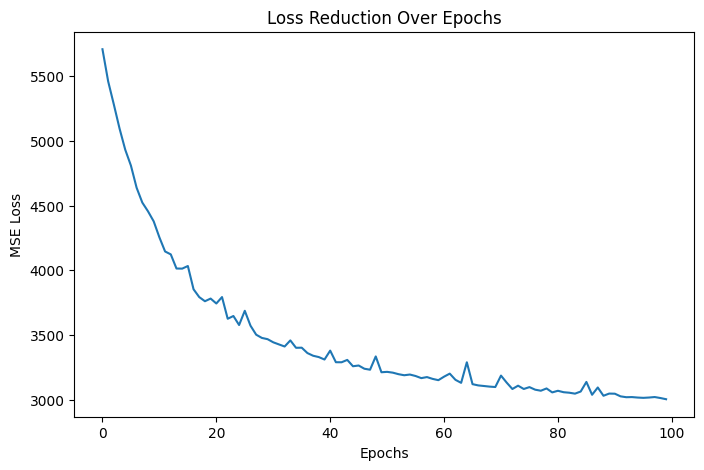

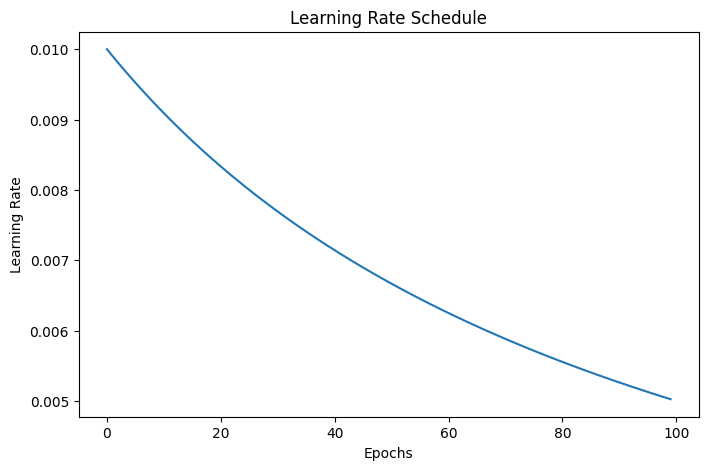

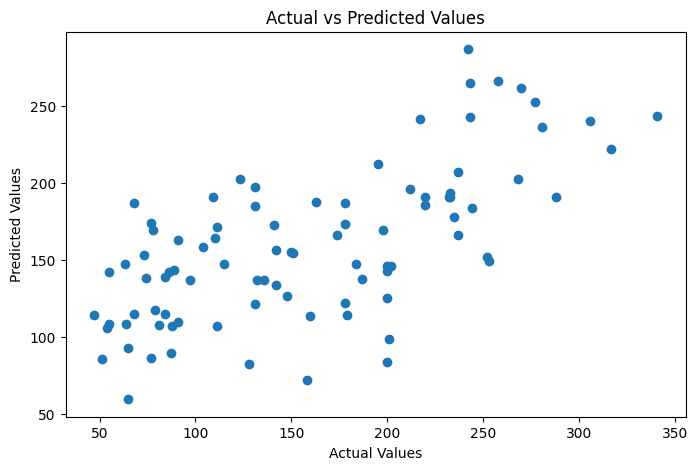

In [12]:

# Loss Curve
plt.plot(range(len(sgd.loss_history)), sgd.loss_history)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss Reduction Over Epochs")
plt.show()

# Learning Rate Decay
plt.plot(range(len(sgd.lr_history)), sgd.lr_history)
plt.xlabel("Epochs")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.show()

# Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()



# Step 7 — Compare with Scikit-learn SGDRegressor

Let's compare our implementation with Scikit-learn's built-in model.


In [13]:
sk_sgd = SGDRegressor(
    max_iter=1000,
    learning_rate='constant',
    eta0=0.01,
    random_state=42
)

sk_sgd.fit(X_train, y_train)

sk_pred = sk_sgd.predict(X_test)

print("Scikit-learn SGD R² Score:", round(r2_score(y_test, sk_pred), 4))


Scikit-learn SGD R² Score: 0.4441



# Step 8 — Visualization

Plot Actual vs Predicted values.


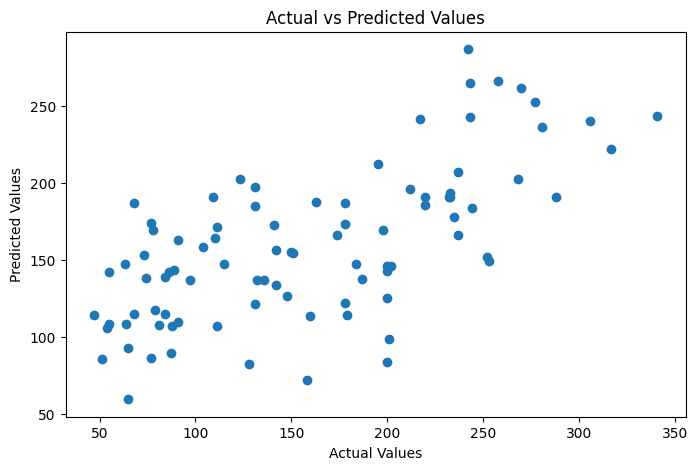

In [14]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()



# Important Concepts Learned

### Machine Learning Concepts
- Multiple Linear Regression
- Loss Minimization
- Gradient Descent
- Stochastic Gradient Descent
- Optimization Algorithms

### Python & NumPy Concepts
- Vectorized Operations
- Dot Product
- Random Sampling
- OOP in Python
- Matrix Computation

---

# Possible Improvements

You can further improve this project by adding:

- Mini Batch Gradient Descent
- Learning Rate Scheduling
- Early Stopping
- Feature Scaling
- Cost Function Tracking
- Animation of Convergence

---

# Final Thoughts

This project demonstrates the **core mathematics behind modern ML optimizers**.

Even high-level ML libraries internally perform operations very similar to what you implemented manually here.

Building algorithms from scratch is one of the best ways to deeply understand Machine Learning.
